In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [129]:
data = pd.read_excel('Oil_prices.xlsx')
#print(data.head())
data.columns[0]
df = pd.DataFrame(data.iloc[2:, 0])
df.rename(columns={df.columns[0]: 'Date'}, inplace=True)
# Konwersja kolumny 'Date' na format daty, zamiana błędnych wartości na NaT
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Usunięcie wierszy, w których 'Date' jest NaT
df = df.dropna(subset=['Date'])

# Wyświetlenie pierwszych kilku wierszy
print(df.head())
df.reset_index(drop=True, inplace=True)



        Date
2 2025-12-01
3 2025-11-24
4 2025-11-17
5 2025-11-10
6 2025-11-03


In [130]:
# Dopasowanie długości kolumny do indeksu ramki danych df
df['PL_exchange_rate'] = data['PL_exchange_rate'].iloc[2:2+len(df)].values

# Wyświetlenie pierwszych kilku wierszy
print(df.head())

# Dopasowanie długości kolumny 'PL_price_with_tax_euro95' do indeksu ramki danych df
df['PL_price_with_tax_euro95'] = data['PL_price_with_tax_euro95'].iloc[2:2+len(df)].values

# Wyświetlenie pierwszych kilku wierszy
print(df.head())

        Date  PL_exchange_rate
0 2025-12-01          0.236502
1 2025-11-24          0.236390
2 2025-11-17          0.236810
3 2025-11-10          0.236183
4 2025-11-03          0.235073
        Date  PL_exchange_rate PL_price_with_tax_euro95
0 2025-12-01          0.236502              1403.045828
1 2025-11-24          0.236390              1412.612609
2 2025-11-17          0.236810              1422.343275
3 2025-11-10          0.236183              1397.697821
4 2025-11-03          0.235073              1391.126604


In [131]:
df['oil price_pln_1l'] = df['PL_price_with_tax_euro95'].astype(float) / df['PL_exchange_rate'].astype(float)/1000
print(df.head())

        Date  PL_exchange_rate PL_price_with_tax_euro95  oil price_pln_1l
0 2025-12-01          0.236502              1403.045828          5.932499
1 2025-11-24          0.236390              1412.612609          5.975775
2 2025-11-17          0.236810              1422.343275          6.006271
3 2025-11-10          0.236183              1397.697821          5.917853
4 2025-11-03          0.235073              1391.126604          5.917853


In [132]:

df = df[['Date', 'oil price_pln_1l','PL_exchange_rate']]
# Wyodrębnienie roku z kolumny 'Date'
df['Rok'] = pd.to_datetime(df['Date']).dt.year

# Obliczenie średniej ceny za każdy rok
yearly_avg = df.groupby('Rok')[['oil price_pln_1l','PL_exchange_rate']].mean().reset_index()

# Wyświetlenie wyników
print(yearly_avg)

     Rok  oil price_pln_1l  PL_exchange_rate
0   2005          4.008775          0.248507
1   2006          3.974898          0.256706
2   2007          4.209776          0.264451
3   2008          4.326512          0.287189
4   2009          4.130460          0.231169
5   2010          4.531652          0.250398
6   2011          5.105678          0.243850
7   2012          5.701362          0.239243
8   2013          5.481981          0.238378
9   2014          5.284635          0.239253
10  2015          4.637420          0.239240
11  2016          4.344827          0.229241
12  2017          4.594558          0.234868
13  2018          4.935844          0.234857
14  2019          4.996935          0.232678
15  2020          4.436279          0.225217
16  2021          5.480915          0.219141
17  2022          6.658548          0.213497
18  2023          6.515409          0.220285
19  2024          6.364379          0.232419
20  2025          5.955447          0.235789


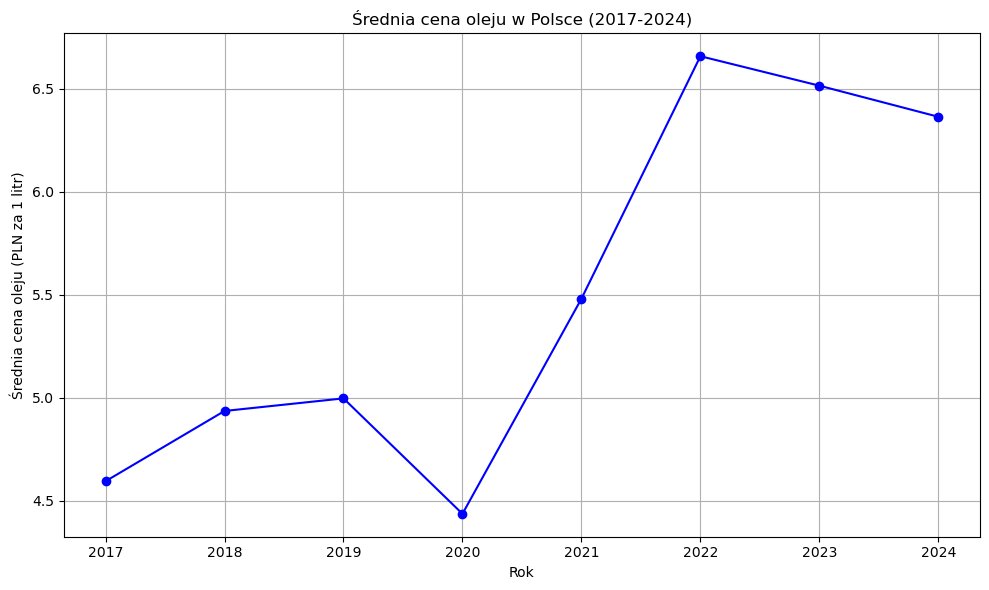

In [133]:
# Filtrowanie danych dla lat od 2017 do 2024
filtered_avg = yearly_avg[(yearly_avg['Rok'] >= 2017) & (yearly_avg['Rok'] <= 2024)]

# Tworzenie wykresu
plt.figure(figsize=(10, 6))
plt.plot(filtered_avg['Rok'], filtered_avg['oil price_pln_1l'], marker='o', linestyle='-', color='blue')
plt.xlabel('Rok')
plt.ylabel('Średnia cena oleju (PLN za 1 litr)')
plt.title('Średnia cena oleju w Polsce (2017-2024)')
plt.grid(True)
plt.xticks(filtered_avg['Rok'])
plt.tight_layout()
plt.show()

In [134]:
cena_energii = pd.read_excel('średnia_cena_energii.xlsx')

# Weź kolumny i zrób niezależną kopię
df_energy = cena_energii[['Rok', cena_energii.columns[1]]].copy()

# Zmień nazwę kolumny bez inplace
df_energy = df_energy.rename(columns={df_energy.columns[1]: 'Średnia cena energii'})

print(df_energy.head())

    Rok  Średnia cena energii
0  2024                0.8280
1  2023                0.7840
2  2022                0.7297
3  2021                0.5947
4  2020                0.5374


In [135]:
merged=df_energy.join(yearly_avg.set_index('Rok'), on='Rok', how='inner')
merged

,Rok,Średnia cena energii,oil price_pln_1l,PL_exchange_rate
0,2024,0.8280,6.364379,0.232419
1,2023,0.7840,6.515409,0.220285
2,2022,0.7297,6.658548,0.213497
3,2021,0.5947,5.480915,0.219141
4,2020,0.5374,4.436279,0.225217
5,2019,0.4862,4.996935,0.232678
6,2018,0.5055,4.935844,0.234857
7,2017,0.5046,4.594558,0.234868
8,2016,0.4987,4.344827,0.229241
9,2015,0.5017,4.637420,0.239240


In [136]:
# Pierwszy wiersz to dane, więc brak nagłówków
ilosc_ladowarek = pd.read_excel('ilosc_ladowarek.xlsx', header=None)

# Ustaw własne nazwy kolumn (dopasuj do liczby kolumn w pliku)
ilosc_ladowarek.columns = ['Rok', 'Ilość ładowarek']  # jeśli masz 2 kolumny

print(ilosc_ladowarek.head())

    Rok  Ilość ładowarek
0  2017              552
1  2018              836
2  2019             1120
3  2020             1805
4  2021             2879


In [137]:
merged_ladowarki = merged.join(ilosc_ladowarek.set_index('Rok'), on='Rok', how='inner')
merged_ladowarki

,Rok,Średnia cena energii,oil price_pln_1l,PL_exchange_rate,Ilość ładowarek
0,2024,0.8280,6.364379,0.232419,8659
1,2023,0.7840,6.515409,0.220285,5933
2,2022,0.7297,6.658548,0.213497,4319
3,2021,0.5947,5.480915,0.219141,2879
4,2020,0.5374,4.436279,0.225217,1805
5,2019,0.4862,4.996935,0.232678,1120
6,2018,0.5055,4.935844,0.234857,836
7,2017,0.5046,4.594558,0.234868,552


In [138]:
nowe_rejestracje = pd.read_csv('nowe_rejestracje_pl.csv')
nowe_rejestracje['Nowe rejestracje EV (Y)'] = nowe_rejestracje['BEV'] + nowe_rejestracje['PHEV']
nowe_rejestracje.rename(columns={'Category':'Rok'}, inplace=True)
nowe_rejestracje = nowe_rejestracje[['Rok', 'Nowe rejestracje EV (Y)']]
merged_final = merged_ladowarki.join(nowe_rejestracje.set_index('Rok'), on='Rok', how='inner')
merged_final


,Rok,Średnia cena energii,oil price_pln_1l,PL_exchange_rate,Ilość ładowarek,Nowe rejestracje EV (Y)
0,2024,0.8280,6.364379,0.232419,8659,31466
1,2023,0.7840,6.515409,0.220285,5933,30113
2,2022,0.7297,6.658548,0.213497,4319,22008
3,2021,0.5947,5.480915,0.219141,2879,16320
4,2020,0.5374,4.436279,0.225217,1805,8035
5,2019,0.4862,4.996935,0.232678,1120,2630
6,2018,0.5055,4.935844,0.234857,836,1280
7,2017,0.5046,4.594558,0.234868,552,893


In [139]:
flota_samochodow_ev = pd.read_csv('Poland_Fleet.csv')
flota_samochodow_ev.rename(columns={'Category':'Rok'}, inplace=True)
flota_samochodow_ev['Samochody EV w flocie'] = flota_samochodow_ev['BEV'] + flota_samochodow_ev['PHEV']
flota_samochodow_ev = flota_samochodow_ev[['Rok', 'Samochody EV w flocie']]
final_merged = merged_final.join(flota_samochodow_ev.set_index('Rok'), on='Rok', how='inner')
final_merged['Samochody EV w flocie'] = final_merged['Samochody EV w flocie'].astype(int)
final_merged


,Rok,Średnia cena energii,oil price_pln_1l,PL_exchange_rate,Ilość ładowarek,Nowe rejestracje EV (Y),Samochody EV w flocie
0,2024,0.8280,6.364379,0.232419,8659,31466,141455
1,2023,0.7840,6.515409,0.220285,5933,30113,98348
2,2022,0.7297,6.658548,0.213497,4319,22008,57256
3,2021,0.5947,5.480915,0.219141,2879,16320,33766
4,2020,0.5374,4.436279,0.225217,1805,8035,15691
5,2019,0.4862,4.996935,0.232678,1120,2630,7577
6,2018,0.5055,4.935844,0.234857,836,1280,4610
7,2017,0.5046,4.594558,0.234868,552,893,1712


In [140]:
srednia_cena_ev = pd.read_csv('srednia_cena.csv')
srednia_cena_ev.rename(columns={'Category':'Rok','Purchase price (EUR)':'Średnia cena EV'}, inplace=True)
final_merged = final_merged.join(srednia_cena_ev.set_index('Rok'), on='Rok', how='inner')
final_merged ["Średnia cena EV (PLN)"] = final_merged["Średnia cena EV"] / final_merged['PL_exchange_rate']
final_merged.drop(columns=['Średnia cena EV'], inplace=True)
final_merged
final_merged['Cena ładowania na stacji (PLN/kWh)'] = final_merged['Średnia cena energii'] * 3  # zakładając 300% marżę
final_merged

,Rok,Średnia cena energii,oil price_pln_1l,PL_exchange_rate,Ilość ładowarek,Nowe rejestracje EV (Y),Samochody EV w flocie,Średnia cena EV (PLN),Cena ładowania na stacji (PLN/kWh)
0,2024,0.8280,6.364379,0.232419,8659,31466,141455,206308.234007,2.4840
1,2023,0.7840,6.515409,0.220285,5933,30113,98348,208816.368112,2.3520
2,2022,0.7297,6.658548,0.213497,4319,22008,57256,205503.244553,2.1891
3,2021,0.5947,5.480915,0.219141,2879,16320,33766,185930.601405,1.7841
4,2020,0.5374,4.436279,0.225217,1805,8035,15691,170108.962017,1.6122
5,2019,0.4862,4.996935,0.232678,1120,2630,7577,181529.621445,1.4586
6,2018,0.5055,4.935844,0.234857,836,1280,4610,196825.569894,1.5165
7,2017,0.5046,4.594558,0.234868,552,893,1712,190395.891871,1.5138


In [141]:
data = pd.read_csv('gdp_data.csv')
data.head()
polska_pps = data[(data['geo'] == 'Poland') & (data['unit'] == 'Current prices, purchasing power standard (PPS, EU27 from 2020) per capita')]
polska_pps = polska_pps[['TIME_PERIOD', 'OBS_VALUE']]
polska_pps.rename(columns={'OBS_VALUE':'GDP per capita (PPS) (X1)','TIME_PERIOD':'Rok'}, inplace=True)
final_merged = final_merged.join(polska_pps.set_index('Rok'), on='Rok', how='inner')
final_merged

,Rok,Średnia cena energii,oil price_pln_1l,PL_exchange_rate,Ilość ładowarek,Nowe rejestracje EV (Y),Samochody EV w flocie,Średnia cena EV (PLN),Cena ładowania na stacji (PLN/kWh),GDP per capita (PPS) (X1)
0,2024,0.8280,6.364379,0.232419,8659,31466,141455,206308.234007,2.4840,31439.0
1,2023,0.7840,6.515409,0.220285,5933,30113,98348,208816.368112,2.3520,29572.1
2,2022,0.7297,6.658548,0.213497,4319,22008,57256,205503.244553,2.1891,28149.4
3,2021,0.5947,5.480915,0.219141,2879,16320,33766,185930.601405,1.7841,26195.3
4,2020,0.5374,4.436279,0.225217,1805,8035,15691,170108.962017,1.6122,23914.3
5,2019,0.4862,4.996935,0.232678,1120,2630,7577,181529.621445,1.4586,23345.3
6,2018,0.5055,4.935844,0.234857,836,1280,4610,196825.569894,1.5165,21942.4
7,2017,0.5046,4.594558,0.234868,552,893,1712,190395.891871,1.5138,20729.9


In [142]:
final_merged["Wskaźnik infrastruktury EV (X4)"] = final_merged['Ilość ładowarek'] / final_merged['Samochody EV w flocie'] 
final_merged

,Rok,Średnia cena energii,oil price_pln_1l,PL_exchange_rate,Ilość ładowarek,Nowe rejestracje EV (Y),Samochody EV w flocie,Średnia cena EV (PLN),Cena ładowania na stacji (PLN/kWh),GDP per capita (PPS) (X1),Wskaźnik infrastruktury EV (X4)
0,2024,0.8280,6.364379,0.232419,8659,31466,141455,206308.234007,2.4840,31439.0,0.061214
1,2023,0.7840,6.515409,0.220285,5933,30113,98348,208816.368112,2.3520,29572.1,0.060327
2,2022,0.7297,6.658548,0.213497,4319,22008,57256,205503.244553,2.1891,28149.4,0.075433
3,2021,0.5947,5.480915,0.219141,2879,16320,33766,185930.601405,1.7841,26195.3,0.085263
4,2020,0.5374,4.436279,0.225217,1805,8035,15691,170108.962017,1.6122,23914.3,0.115034
5,2019,0.4862,4.996935,0.232678,1120,2630,7577,181529.621445,1.4586,23345.3,0.147816
6,2018,0.5055,4.935844,0.234857,836,1280,4610,196825.569894,1.5165,21942.4,0.181345
7,2017,0.5046,4.594558,0.234868,552,893,1712,190395.891871,1.5138,20729.9,0.322430


In [143]:
average_fuel_consumption = 7  # Średnie zużycie paliwa w litrach na 100 km
average_energy_consumption_ev = 18  # Średnie zużycie energii przez EV w kWh na 100 km
k_ice = final_merged['oil price_pln_1l'] * average_fuel_consumption   # Koszt paliwa na 100 km
k_ev = (0.8 * final_merged['Średnia cena energii'] + 0.2 * final_merged['Cena ładowania na stacji (PLN/kWh)']) * average_energy_consumption_ev # Koszt energii na 100 km
final_merged["Opłacalność jazdy (X2)"] = k_ice / k_ev
final_merged

,Rok,Średnia cena energii,oil price_pln_1l,PL_exchange_rate,Ilość ładowarek,Nowe rejestracje EV (Y),Samochody EV w flocie,Średnia cena EV (PLN),Cena ładowania na stacji (PLN/kWh),GDP per capita (PPS) (X1),Wskaźnik infrastruktury EV (X4),Opłacalność jazdy (X2)
0,2024,0.8280,6.364379,0.232419,8659,31466,141455,206308.234007,2.4840,31439.0,0.061214,2.135124
1,2023,0.7840,6.515409,0.220285,5933,30113,98348,208816.368112,2.3520,29572.1,0.060327,2.308464
2,2022,0.7297,6.658548,0.213497,4319,22008,57256,205503.244553,2.1891,28149.4,0.075433,2.534736
3,2021,0.5947,5.480915,0.219141,2879,16320,33766,185930.601405,1.7841,26195.3,0.085263,2.560075
4,2020,0.5374,4.436279,0.225217,1805,8035,15691,170108.962017,1.6122,23914.3,0.115034,2.293077
5,2019,0.4862,4.996935,0.232678,1120,2630,7577,181529.621445,1.4586,23345.3,0.147816,2.854870
6,2018,0.5055,4.935844,0.234857,836,1280,4610,196825.569894,1.5165,21942.4,0.181345,2.712300
7,2017,0.5046,4.594558,0.234868,552,893,1712,190395.891871,1.5138,20729.9,0.322430,2.529263


In [144]:
# ...existing code...

# Tabela z kwotami dotacji
dotacje = pd.DataFrame({
    'Rok': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'Uśredniona Kwota Dotacji (PLN)': [0, 0, 0, 18750, 27000, 27000, 27000, 27000]
})

# Dołącz do final_merged po kolumnie 'Rok'
final_merged = final_merged.join(dotacje.set_index('Rok'), on='Rok', how='left')
final_merged
# ...existing code...

,Rok,Średnia cena energii,oil price_pln_1l,PL_exchange_rate,Ilość ładowarek,Nowe rejestracje EV (Y),Samochody EV w flocie,Średnia cena EV (PLN),Cena ładowania na stacji (PLN/kWh),GDP per capita (PPS) (X1),Wskaźnik infrastruktury EV (X4),Opłacalność jazdy (X2),Uśredniona Kwota Dotacji (PLN)
0,2024,0.8280,6.364379,0.232419,8659,31466,141455,206308.234007,2.4840,31439.0,0.061214,2.135124,27000
1,2023,0.7840,6.515409,0.220285,5933,30113,98348,208816.368112,2.3520,29572.1,0.060327,2.308464,27000
2,2022,0.7297,6.658548,0.213497,4319,22008,57256,205503.244553,2.1891,28149.4,0.075433,2.534736,27000
3,2021,0.5947,5.480915,0.219141,2879,16320,33766,185930.601405,1.7841,26195.3,0.085263,2.560075,27000
4,2020,0.5374,4.436279,0.225217,1805,8035,15691,170108.962017,1.6122,23914.3,0.115034,2.293077,18750
5,2019,0.4862,4.996935,0.232678,1120,2630,7577,181529.621445,1.4586,23345.3,0.147816,2.854870,0
6,2018,0.5055,4.935844,0.234857,836,1280,4610,196825.569894,1.5165,21942.4,0.181345,2.712300,0
7,2017,0.5046,4.594558,0.234868,552,893,1712,190395.891871,1.5138,20729.9,0.322430,2.529263,0


In [145]:
final_merged["Wskaźnik wsparcia (X3)"] = final_merged['Uśredniona Kwota Dotacji (PLN)'] / final_merged ["Średnia cena EV (PLN)"]
final_merged

,Rok,Średnia cena energii,oil price_pln_1l,PL_exchange_rate,Ilość ładowarek,Nowe rejestracje EV (Y),Samochody EV w flocie,Średnia cena EV (PLN),Cena ładowania na stacji (PLN/kWh),GDP per capita (PPS) (X1),Wskaźnik infrastruktury EV (X4),Opłacalność jazdy (X2),Uśredniona Kwota Dotacji (PLN),Wskaźnik wsparcia (X3)
0,2024,0.8280,6.364379,0.232419,8659,31466,141455,206308.234007,2.4840,31439.0,0.061214,2.135124,27000,0.130872
1,2023,0.7840,6.515409,0.220285,5933,30113,98348,208816.368112,2.3520,29572.1,0.060327,2.308464,27000,0.129300
2,2022,0.7297,6.658548,0.213497,4319,22008,57256,205503.244553,2.1891,28149.4,0.075433,2.534736,27000,0.131385
3,2021,0.5947,5.480915,0.219141,2879,16320,33766,185930.601405,1.7841,26195.3,0.085263,2.560075,27000,0.145215
4,2020,0.5374,4.436279,0.225217,1805,8035,15691,170108.962017,1.6122,23914.3,0.115034,2.293077,18750,0.110223
5,2019,0.4862,4.996935,0.232678,1120,2630,7577,181529.621445,1.4586,23345.3,0.147816,2.854870,0,0.000000
6,2018,0.5055,4.935844,0.234857,836,1280,4610,196825.569894,1.5165,21942.4,0.181345,2.712300,0,0.000000
7,2017,0.5046,4.594558,0.234868,552,893,1712,190395.891871,1.5138,20729.9,0.322430,2.529263,0,0.000000


In [146]:
# Nowa tabela z Y i X1-X4
Y = final_merged[['Samochody EV w flocie']].copy()
X = final_merged[['GDP per capita (PPS) (X1)', 'Opłacalność jazdy (X2)', 'Wskaźnik wsparcia (X3)', 'Wskaźnik infrastruktury EV (X4)']].copy()

# Połącz w jedną tabelę (jeśli chcesz mieć wszystko razem)
tabela_model = pd.concat([Y, X], axis=1)
print(tabela_model)

   Samochody EV w flocie  GDP per capita (PPS) (X1)  Opłacalność jazdy (X2)  \
0                 141455                    31439.0                2.135124   
1                  98348                    29572.1                2.308464   
2                  57256                    28149.4                2.534736   
3                  33766                    26195.3                2.560075   
4                  15691                    23914.3                2.293077   
5                   7577                    23345.3                2.854870   
6                   4610                    21942.4                2.712300   
7                   1712                    20729.9                2.529263   

   Wskaźnik wsparcia (X3)  Wskaźnik infrastruktury EV (X4)  
0                0.130872                         0.061214  
1                0.129300                         0.060327  
2                0.131385                         0.075433  
3                0.145215                   

Macierz korelacji:
                                 Samochody EV w flocie  \
Samochody EV w flocie                         1.000000   
GDP per capita (PPS) (X1)                     0.949798   
Opłacalność jazdy (X2)                       -0.745861   
Wskaźnik wsparcia (X3)                        0.672742   
Wskaźnik infrastruktury EV (X4)              -0.670116   

                                 GDP per capita (PPS) (X1)  \
Samochody EV w flocie                             0.949798   
GDP per capita (PPS) (X1)                         1.000000   
Opłacalność jazdy (X2)                           -0.657318   
Wskaźnik wsparcia (X3)                            0.816711   
Wskaźnik infrastruktury EV (X4)                  -0.840874   

                                 Opłacalność jazdy (X2)  \
Samochody EV w flocie                         -0.745861   
GDP per capita (PPS) (X1)                     -0.657318   
Opłacalność jazdy (X2)                         1.000000   
Wskaźnik wsparcia (X3) 

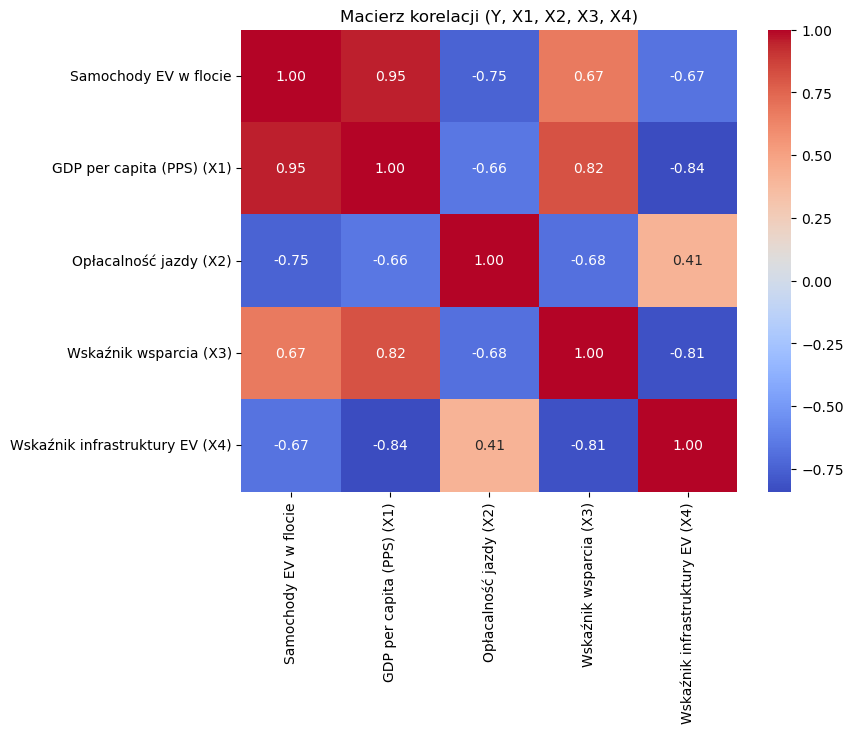

In [147]:
# Macierz korelacji
corr_matrix = tabela_model.corr()
print("Macierz korelacji:")
print(corr_matrix)

# Opcjonalnie: wizualizacja korelacji
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Macierz korelacji (Y, X1, X2, X3, X4)")
plt.show()

In [149]:
# Korelacja Y z X1-X4
corr_y = tabela_model.corr()['Samochody EV w flocie'][1:]  # pomijamy korelację Y z samym sobą
print("Korelacja Y z X1-X4:")
print(corr_y)

Korelacja Y z X1-X4:
GDP per capita (PPS) (X1)          0.949798
Opłacalność jazdy (X2)            -0.745861
Wskaźnik wsparcia (X3)             0.672742
Wskaźnik infrastruktury EV (X4)   -0.670116
Name: Samochody EV w flocie, dtype: float64


In [151]:
import statsmodels.api as sm

# Dodanie stałej do modelu (intercept)
X = sm.add_constant(tabela_model[['GDP per capita (PPS) (X1)', 'Opłacalność jazdy (X2)', 
                                 'Wskaźnik wsparcia (X3)', 'Wskaźnik infrastruktury EV (X4)']])
y = tabela_model['Samochody EV w flocie']

# Dopasowanie modelu OLS
model_regresji = sm.OLS(y, X).fit()

# Wyświetlenie kluczowych wyników
print(model_regresji.summary())

                              OLS Regression Results                             
Dep. Variable:     Samochody EV w flocie   R-squared:                       0.993
Model:                               OLS   Adj. R-squared:                  0.983
Method:                    Least Squares   F-statistic:                     101.1
Date:                   Sun, 11 Jan 2026   Prob (F-statistic):            0.00157
Time:                           19:47:27   Log-Likelihood:                -77.884
No. Observations:                      8   AIC:                             165.8
Df Residuals:                          3   BIC:                             166.2
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

c:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=8 observations were given.
  return hypotest_fun_in(*args, **kwds)


   Nowe rejestracje EV (Y)  GDP per capita (PPS) (X1)  Opłacalność jazdy (X2)  \
0                    31466                   1.620426               -1.614516   
1                    30113                   1.096862               -0.828094   
2                    22008                   0.697872                0.198476   
3                    16320                   0.149853                0.313435   
4                     8035                  -0.489844               -0.897902   

   Wskaźnik wsparcia (X3)  Wskaźnik infrastruktury EV (X4)  
0                0.790294                        -0.844782  
1                0.765447                        -0.855505  
2                0.798397                        -0.672918  
3                1.017014                        -0.554105  
4                0.463908                        -0.194276  


                               OLS Regression Results                              
Dep. Variable:     Nowe rejestracje EV (Y)   R-squared:                       0.984
Model:                                 OLS   Adj. R-squared:                  0.964
Method:                      Least Squares   F-statistic:                     47.47
Date:                     Sat, 10 Jan 2026   Prob (F-statistic):            0.00480
Time:                             22:22:01   Log-Likelihood:                -69.771
No. Observations:                        8   AIC:                             149.5
Df Residuals:                            3   BIC:                             149.9
Df Model:                                4                                         
Covariance Type:                 nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

c:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=8 observations were given.
  return hypotest_fun_in(*args, **kwds)
